# Phase 2 – Exploration et préparation des données



In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
df = pd.read_csv("/content/Instagram data.csv", encoding="latin1")
df.head()


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


## Compréhension des données

Nous commençons par examiner les premières lignes du jeu de données
ainsi que les types de variables afin de mieux comprendre sa structure.


In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [36]:
df.describe()


,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,5703.991597,2475.789916,1887.512605,1078.100840,171.092437,153.310924,6.663866,9.361345,173.781513,50.621849,20.756303
std,4843.780105,1489.386348,1884.361443,2613.026132,289.431031,156.317731,3.544576,10.089205,82.378947,87.088402,40.921580
min,1941.000000,1133.000000,116.000000,0.000000,9.000000,22.000000,0.000000,0.000000,72.000000,4.000000,0.000000
25%,3467.000000,1945.000000,726.000000,157.500000,38.000000,65.000000,4.000000,3.000000,121.500000,15.000000,4.000000
50%,4289.000000,2207.000000,1278.000000,326.000000,74.000000,109.000000,6.000000,6.000000,151.000000,23.000000,8.000000
75%,6138.000000,2602.500000,2363.500000,689.500000,196.000000,169.000000,8.000000,13.500000,204.000000,42.000000,18.000000
max,36919.000000,13473.000000,11817.000000,17414.000000,2547.000000,1095.000000,19.000000,75.000000,549.000000,611.000000,260.000000


## Gestion des valeurs manquantes

Nous vérifions la présence de valeurs manquantes dans le jeu de données
afin d’évaluer la qualité des informations disponibles.


In [37]:
df.isna().sum()


,0
Impressions,0
From Home,0
From Hashtags,0
From Explore,0
From Other,0
Saves,0
Comments,0
Shares,0
Likes,0
Profile Visits,0


In [38]:
df.duplicated().sum()


np.int64(17)

## Création de nouvelles variables



In [39]:
# Longueur de la légende (caption)
df["caption_length"] = df["Caption"].apply(len)

# Nombre de hashtags
df["hashtags_count"] = df["Hashtags"].apply(lambda x: len(str(x).split()))

# Taux d'engagement
df["engagement"] = (df["Likes"] + df["Comments"] + df["Shares"]) / df["Impressions"]

df[["caption_length", "hashtags_count", "engagement"]].head()



,caption_length,hashtags_count,engagement
0,112,22,0.044898
1,187,18,0.045421
2,117,18,0.035563
3,202,11,0.050795
4,178,29,0.052423


## Analyse descriptive des indicateurs d’engagement

Nous analysons les statistiques principales des variables liées
à l’engagement afin de mieux comprendre leur distribution.


In [40]:
df[["Impressions", "Likes", "Comments", "Shares", "Saves", "engagement"]].describe()


,Impressions,Likes,Comments,Shares,Saves,engagement
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,5703.991597,173.781513,6.663866,9.361345,153.310924,0.037398
std,4843.780105,82.378947,3.544576,10.089205,156.317731,0.009099
min,1941.000000,72.000000,0.000000,0.000000,22.000000,0.012839
25%,3467.000000,121.500000,4.000000,3.000000,65.000000,0.031462
50%,4289.000000,151.000000,6.000000,6.000000,109.000000,0.037771
75%,6138.000000,204.000000,8.000000,13.500000,169.000000,0.042463
max,36919.000000,549.000000,19.000000,75.000000,1095.000000,0.059970


## Analyse des corrélations




In [41]:
df[["Impressions", "Likes", "Comments", "Shares", "Saves", "engagement"]].corr()


,Impressions,Likes,Comments,Shares,Saves,engagement
Impressions,1.000000,0.849835,-0.028524,0.634675,0.779231,-0.537958
Likes,0.849835,1.000000,0.123586,0.707794,0.845643,-0.208972
Comments,-0.028524,0.123586,1.000000,0.016933,-0.026912,0.252776
Shares,0.634675,0.707794,0.016933,1.000000,0.860324,-0.040092
Saves,0.779231,0.845643,-0.026912,0.860324,1.000000,-0.181713
engagement,-0.537958,-0.208972,0.252776,-0.040092,-0.181713,1.000000


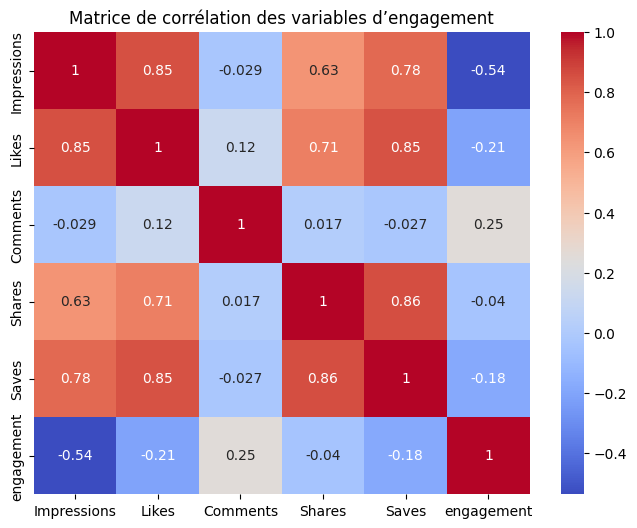

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[["Impressions", "Likes", "Comments", "Shares", "Saves", "engagement"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Matrice de corrélation des variables d’engagement")
plt.show()


## Analyse graphique des facteurs de contenu


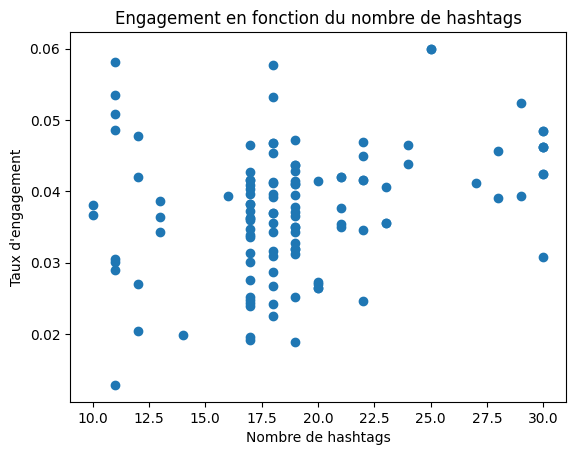

In [43]:
plt.scatter(df["hashtags_count"], df["engagement"])
plt.xlabel("Nombre de hashtags")
plt.ylabel("Taux d'engagement")
plt.title("Engagement en fonction du nombre de hashtags")
plt.show()


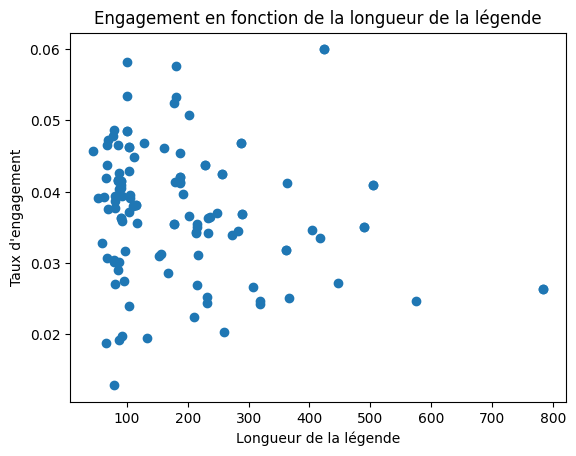

In [44]:
plt.scatter(df["caption_length"], df["engagement"])
plt.xlabel("Longueur de la légende")
plt.ylabel("Taux d'engagement")
plt.title("Engagement en fonction de la longueur de la légende")
plt.show()


## Analyse des sources d’impressions


In [45]:
df[["From Home", "From Hashtags", "From Explore", "From Other"]].mean()


,0
From Home,2475.789916
From Hashtags,1887.512605
From Explore,1078.100840
From Other,171.092437


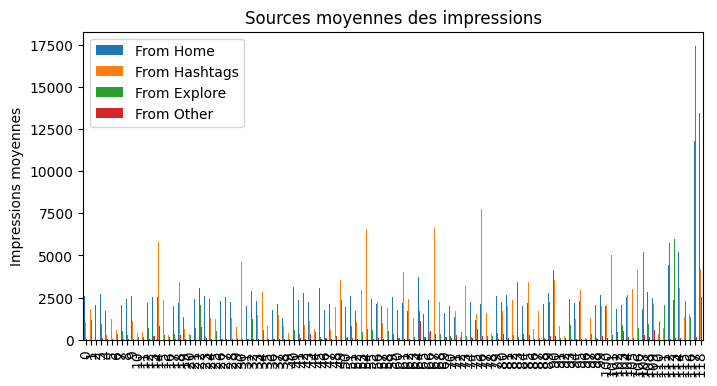

In [46]:
df[["From Home", "From Hashtags", "From Explore", "From Other"]].plot(
    kind="bar",
    figsize=(8,4)
)
plt.ylabel("Impressions moyennes")
plt.title("Sources moyennes des impressions")
plt.show()
